# Project 1 — Customer Segmentation & Retention Analysis

Built this to practice RFM analysis and clustering on real retail data.
Dataset has 1M+ rows of UK e-commerce transactions from 2009-2011.

The Railofy connection: at my internship I tracked outlet ratings manually
across 40+ locations. A model like this would have flagged at-risk customers
automatically instead of waiting for ratings to drop.

Approach: RFM table → StandardScaler → KMeans (k=4) → Segment labelling

In [10]:
# standard libraries i need for this project
# pandas for data tables, numpy for math
# matplotlib and seaborn for charts
# sklearn for the actual ML part

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("All libraries loaded Successfully!")

All libraries loaded Successfully!


In [11]:
# loading the dataset from my local folder
# had to add encoding='latin-1' because it was throwing an error without it

df = pd.read_csv("D:\\Data_Science\\Projects\\Project 1\\Dataset\\archive\\online_retail_II.csv", encoding='latin-1')

print("Shape of data:", df.shape)
df.head()

Shape of data: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
# removing rows where customer ID is missing - cant segment unknown customers
df = df.dropna(subset=['Customer ID'])

# invoices starting with C are cancellations - dont want those
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# negative quantity and zero price rows are bad data
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# total spend per transaction
df['TotalAmount'] = df['Quantity'] * df['Price']

# converting date column so python understands it properly
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Data after cleaning:")
print("Rows remaining:", len(df))
print("Any missing values left?")
print(df.isnull().sum())

Data after cleaning:
Rows remaining: 805549
Any missing values left?
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalAmount    0
dtype: int64


In [13]:
# RFM stands for:
# R = Recency   → How many days ago did the customer last buy?
# F = Frequency → How many times did they buy total?
# M = Monetary  → How much total money did they spend?

# We pick the day AFTER the last invoice as our "today"
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Now build one row per customer with their R, F, M values
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print("RFM Table created!")
print("Number of unique customers:", len(rfm))
rfm.head(10)

RFM Table created!
Number of unique customers: 5878


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


In [14]:
# monetary values go up to 400k while recency is max 375
# if i dont scale, monetary will dominate the clustering completely
# StandardScaler brings everything to the same range

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# tried n_clusters=3 first but segments werent distinct enough
# 4 clusters gave much cleaner separation
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Clustering done!")
print("Customers per cluster:")
print(rfm['Cluster'].value_counts())

Clustering done!
Customers per cluster:
Cluster
1    3841
0    1998
2      35
3       4
Name: count, dtype: int64


In [15]:
# checking what each cluster actually looks like
# average R, F, M per group so i can label them properly

cluster_summary = rfm.groupby('Cluster').agg(
    Recency   = ('Recency', 'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary', 'mean'),
    Count     = ('Customer ID', 'count')
).round(1)

print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0          463.0        2.2     765.2   1998
1           67.0        7.3    3009.4   3841
2           25.9      103.7   83086.1     35
3            3.5      212.5  436835.8      4


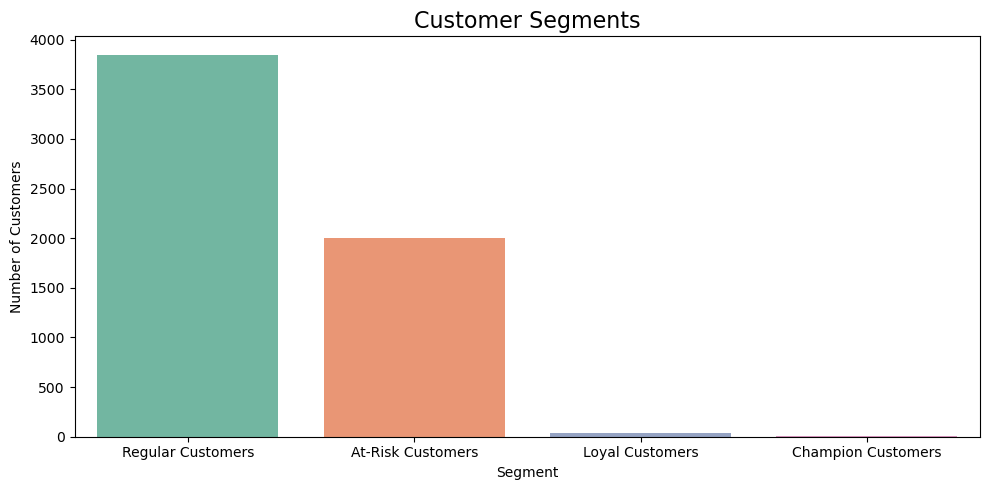

Segment breakdown:
Segment
Regular Customers     3841
At-Risk Customers     1998
Loyal Customers         35
Champion Customers       4
Name: count, dtype: int64


In [16]:
# naming clusters based on what i saw in the summary above
# cluster 3 has highest frequency and spend = champions
# cluster 0 hasnt bought in 463 days = at risk

cluster_names = {
    0: 'At-Risk Customers',
    1: 'Regular Customers',
    2: 'Loyal Customers',
    3: 'Champion Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, x='Segment', hue='Segment', palette='Set2', legend=False)
plt.title('Customer Segments', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Segment breakdown:")
print(rfm['Segment'].value_counts())

In [17]:
# this is the part that connects data to actual business decisions
# at railofy i managed outlet ratings manually - this kind of segmentation
# would have helped identify which customers were about to churn

print("=" * 60)
print("PROJECT 1 - CUSTOMER SEGMENTATION RESULTS")
print("=" * 60)

print("""
SEGMENT ANALYSIS:

1. CHAMPION CUSTOMERS (4 customers)
   - Recency: ~3 days | Frequency: 212 orders | Spend: £436,835
   - Action: VIP treatment, early product access, personal manager

2. LOYAL CUSTOMERS (35 customers)
   - Recency: ~26 days | Frequency: 103 orders | Spend: £83,086
   - Action: Loyalty rewards, referral bonuses, push to champion tier

3. REGULAR CUSTOMERS (3,841 customers)
   - Recency: ~67 days | Frequency: 7 orders | Spend: £3,009
   - Action: Email campaigns, seasonal offers, cross-sell suggestions

4. AT-RISK CUSTOMERS (1,998 customers)
   - Recency: ~463 days | Frequency: 2 orders | Spend: £765
   - Action: Win-back email with discount, limited time offer
""")

rfm.to_csv("D:\\Data_Science\\Projects\\Project 1\\rfm_segmentation_results.csv", index=False)
print("Results saved!")
print("PROJECT 1 COMPLETE!")

PROJECT 1 - CUSTOMER SEGMENTATION RESULTS

SEGMENT ANALYSIS:

1. CHAMPION CUSTOMERS (4 customers)
   - Recency: ~3 days | Frequency: 212 orders | Spend: £436,835
   - Action: VIP treatment, early product access, personal manager

2. LOYAL CUSTOMERS (35 customers)
   - Recency: ~26 days | Frequency: 103 orders | Spend: £83,086
   - Action: Loyalty rewards, referral bonuses, push to champion tier

3. REGULAR CUSTOMERS (3,841 customers)
   - Recency: ~67 days | Frequency: 7 orders | Spend: £3,009
   - Action: Email campaigns, seasonal offers, cross-sell suggestions

4. AT-RISK CUSTOMERS (1,998 customers)
   - Recency: ~463 days | Frequency: 2 orders | Spend: £765
   - Action: Win-back email with discount, limited time offer

Results saved!
PROJECT 1 COMPLETE!
